# TM10007 Machine Learning Group 10 Liver 

In [49]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [50]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from scipy.stats import zscore, shapiro
from sklearn.pipeline import Pipeline

## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [51]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [52]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [53]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [54]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423


In [55]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Removing data with zero variance

In [56]:
from sklearn.feature_selection import VarianceThreshold

# Keep only numeric columns (if not already done)
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Only apply VarianceThreshold if any features have zero variance
zv_selector = VarianceThreshold(threshold=0)
zv_selector.fit(X_train)

support_mask = zv_selector.get_support()
n_removed = len(support_mask) - sum(support_mask)

if n_removed > 0:
    X_train = pd.DataFrame(zv_selector.transform(X_train), columns=X_train.columns[support_mask])
    X_test = pd.DataFrame(zv_selector.transform(X_test), columns=X_test.columns[support_mask])
    print(f"Number of features removed due to zero variance: {n_removed}")
else:
    print("No features with zero variance found — skipping removal.")


Number of features removed due to zero variance: 17


### Scaling the data

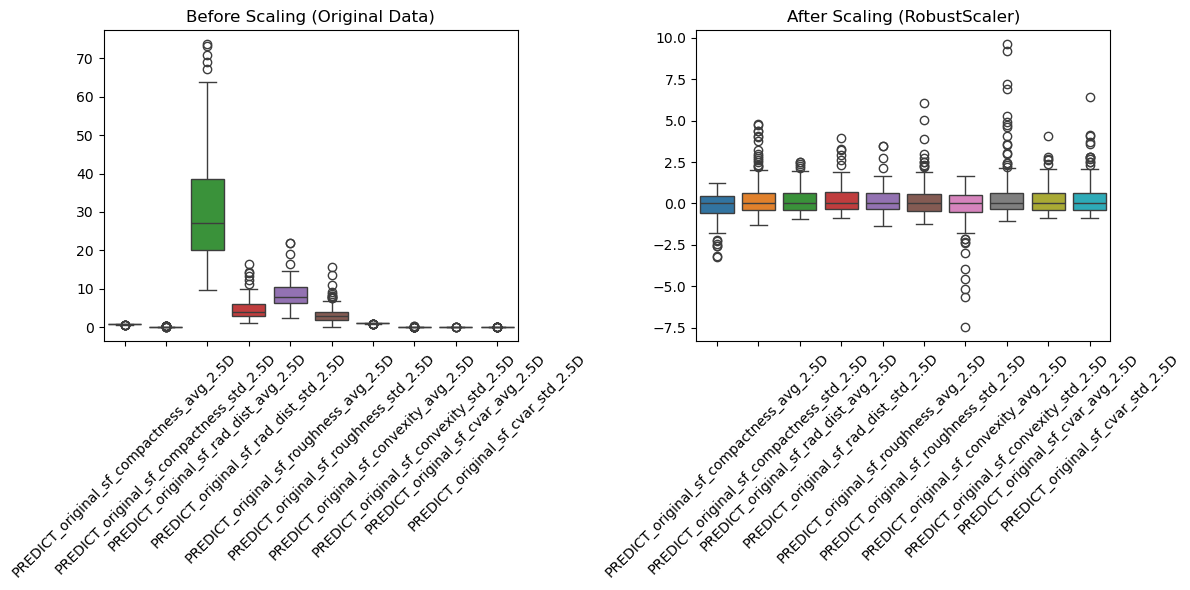

In [57]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Feature selection


=== Evaluating with PCA ===

Model: kNN
  Avg accuracy: 0.582

Model: SVM
  Avg accuracy: 0.500

Model: RandomForest
  Avg accuracy: 0.663

=== Evaluating with SelectKBest ===

Model: kNN
  Avg accuracy: 0.709

Model: SVM


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


  Avg accuracy: 0.737

Model: RandomForest


c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 84  90 412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\anouk\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


  Avg accuracy: 0.723


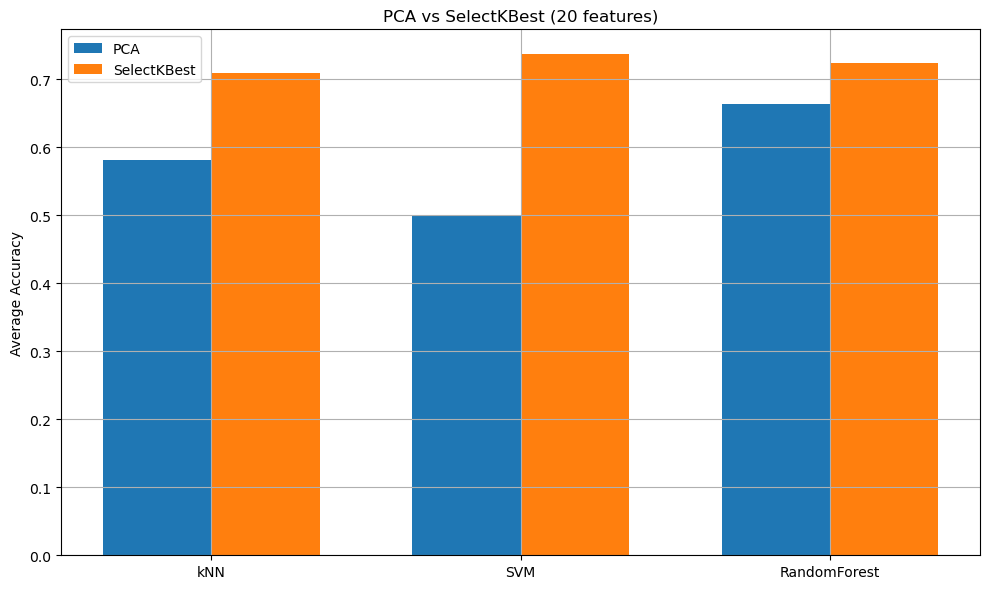

In [58]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Models to test
models = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier()
}

# Prepare StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
results = {}

# Loop over dimensionality reduction methods
for method_name in ["PCA", "SelectKBest"]:
    print(f"\n=== Evaluating with {method_name} ===")
    method_results = {}

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")
        accuracies = []

        for train_idx, test_idx in kf.split(X_train_scaled, y_train):
            X_fold_train, X_fold_test = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[test_idx]
            y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

            # Apply dimensionality reduction
            if method_name == "PCA":
                reducer = PCA(n_components=50)
            elif method_name == "SelectKBest":
                reducer = SelectKBest(f_classif, k=50)

            X_fold_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
            X_fold_test_reduced = reducer.transform(X_fold_test)

            # Train model
            model.fit(X_fold_train_reduced, y_fold_train)
            y_pred = model.predict(X_fold_test_reduced)
            acc = accuracy_score(y_fold_test, y_pred)
            accuracies.append(acc)

        avg_acc = np.mean(accuracies)
        print(f"  Avg accuracy: {avg_acc:.3f}")
        method_results[model_name] = avg_acc

    results[method_name] = method_results

# === Plot comparison ===
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.35

pca_scores = [results["PCA"][label] for label in labels]
skb_scores = [results["SelectKBest"][label] for label in labels]

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, pca_scores, width, label='PCA')
plt.bar(x + width/2, skb_scores, width, label='SelectKBest')
plt.ylabel('Average Accuracy')
plt.title('PCA vs SelectKBest (20 features)')
plt.xticks(x, labels)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Evaluating kNN...


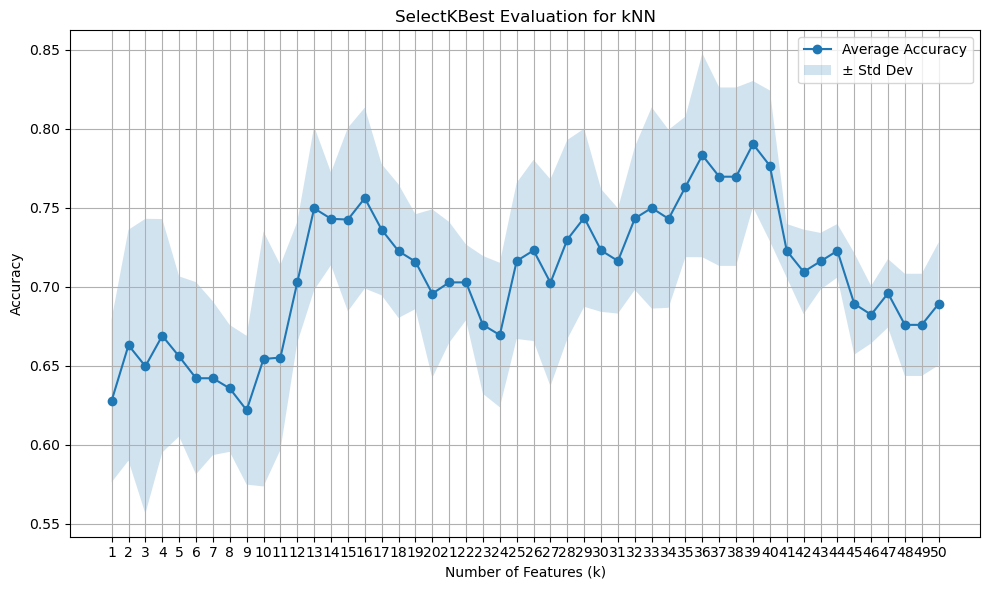


Evaluating SVM...


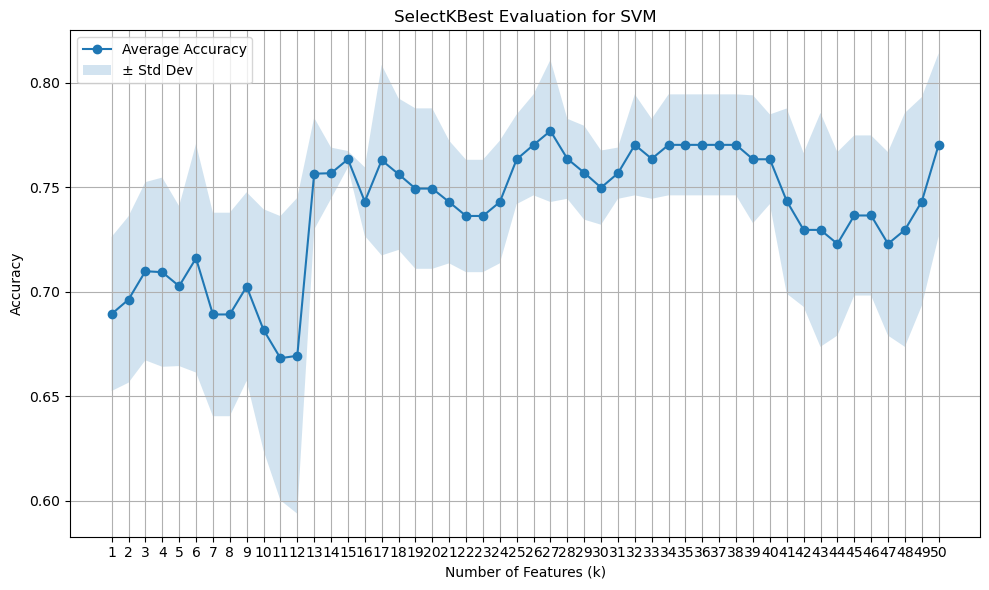


Evaluating RandomForest...


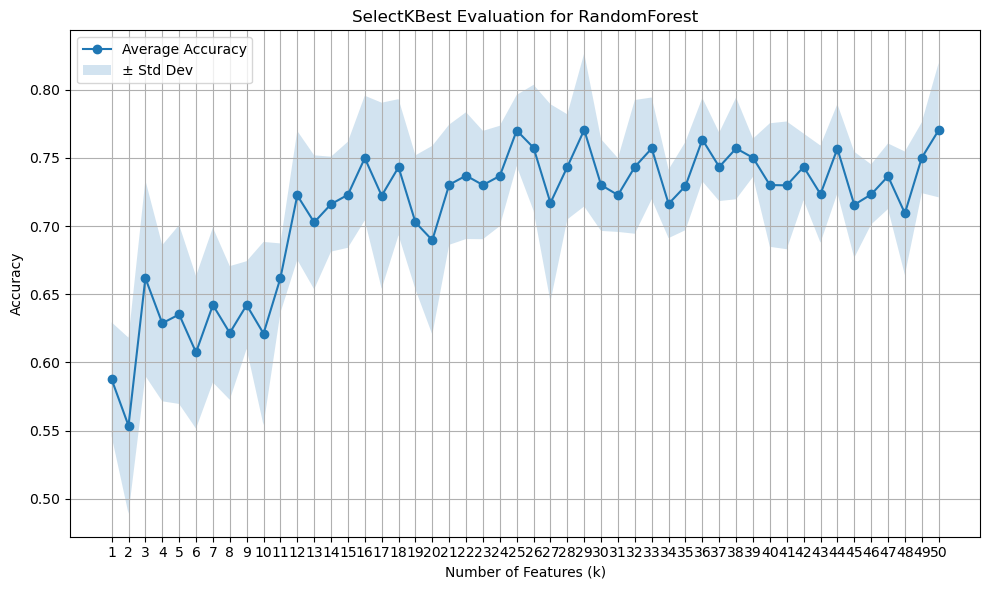

In [59]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Model dictionary
models = {
    "kNN": (KNeighborsClassifier(), X_train_scaled),
    "SVM": (SVC(kernel="rbf"), X_train_scaled),
    "RandomForest": (RandomForestClassifier(), X_train)  # scaling not needed
}

k_values = range(1, 51)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Result storage
results = {}

for model_name, (model, X_input) in models.items():
    print(f"\nEvaluating {model_name}...")
    average_accuracies = []
    std_accuracies = []

    for k in k_values:
        selector = SelectKBest(f_classif, k=k)
        X_selected = selector.fit_transform(X_input, y_train)
        accuracies = []

        for train_index, test_index in kf.split(X_selected, y_train):
            X_fold_train, X_fold_test = X_selected[train_index], X_selected[test_index]
            y_fold_train, y_fold_test = y_train.iloc[train_index], y_train.iloc[test_index]

            model.fit(X_fold_train, y_fold_train)
            y_pred = model.predict(X_fold_test)
            acc = accuracy_score(y_fold_test, y_pred)
            accuracies.append(acc)

        avg_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        average_accuracies.append(avg_acc)
        std_accuracies.append(std_acc)

    # Save results for plotting
    results[model_name] = {
        "avg": average_accuracies,
        "std": std_accuracies
    }

    # Plot
    upper = np.array(average_accuracies) + np.array(std_accuracies)
    lower = np.array(average_accuracies) - np.array(std_accuracies)

    plt.figure(figsize=(10, 6))
    plt.plot(list(k_values), average_accuracies, marker='o', label='Average Accuracy')
    plt.fill_between(list(k_values), upper, lower, alpha=0.2, label='± Std Dev')
    plt.title(f'SelectKBest Evaluation for {model_name}')
    plt.xlabel('Number of Features (k)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(list(k_values))
    plt.legend()
    plt.tight_layout()
    plt.show()


kNN → beste k = 39


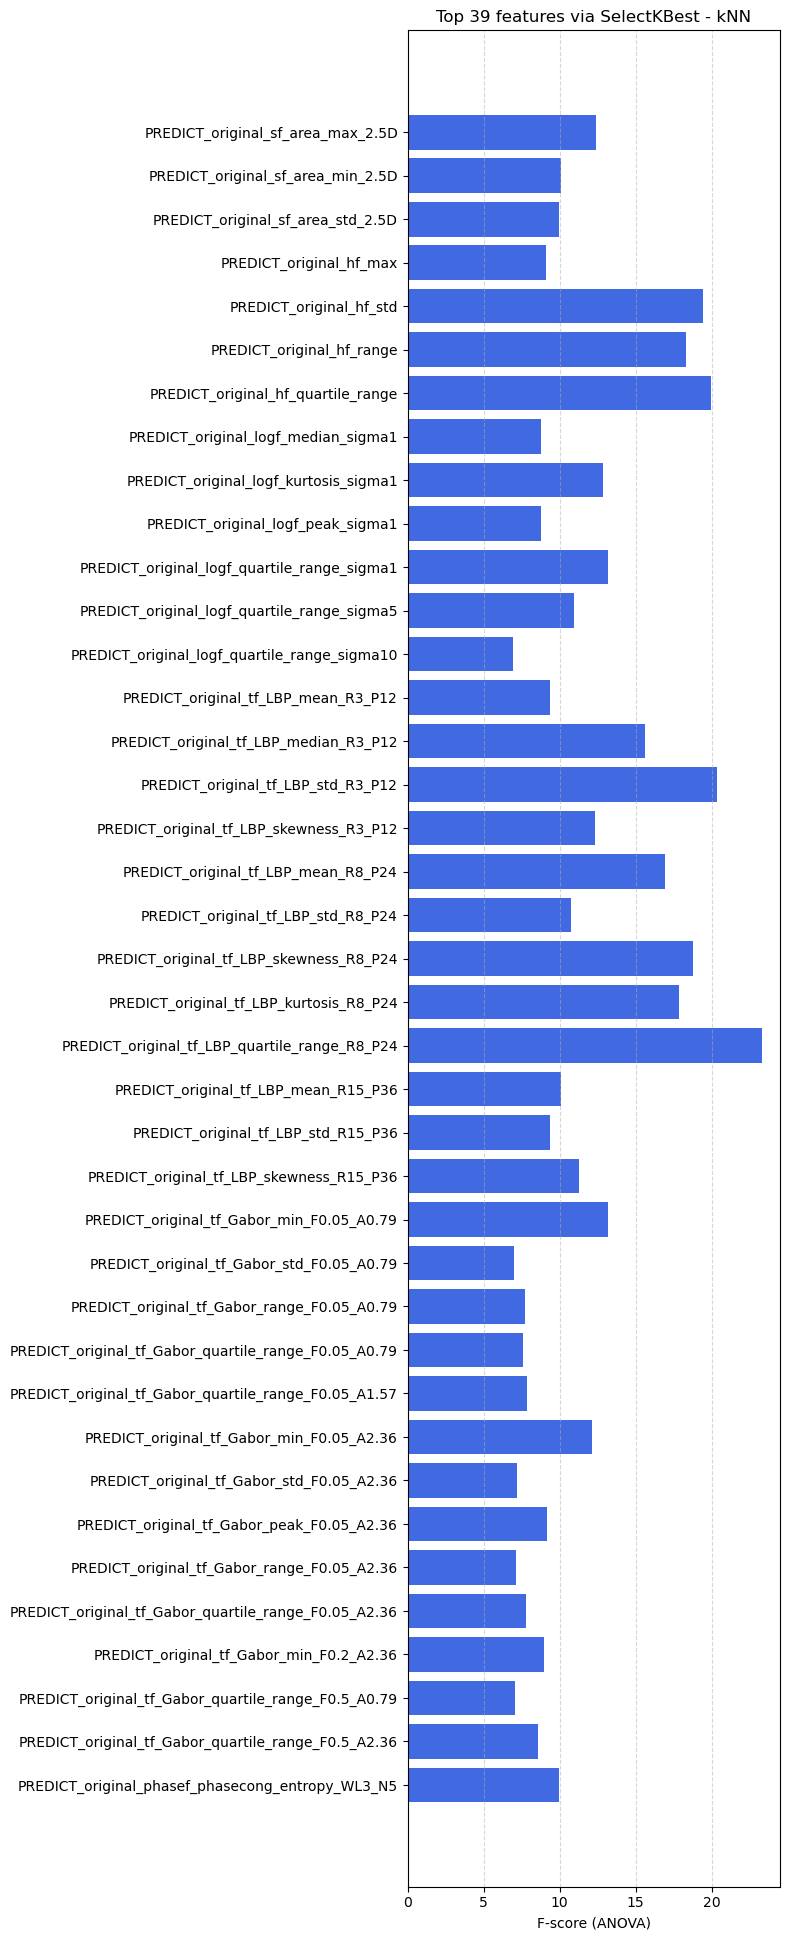

SVM → beste k = 27


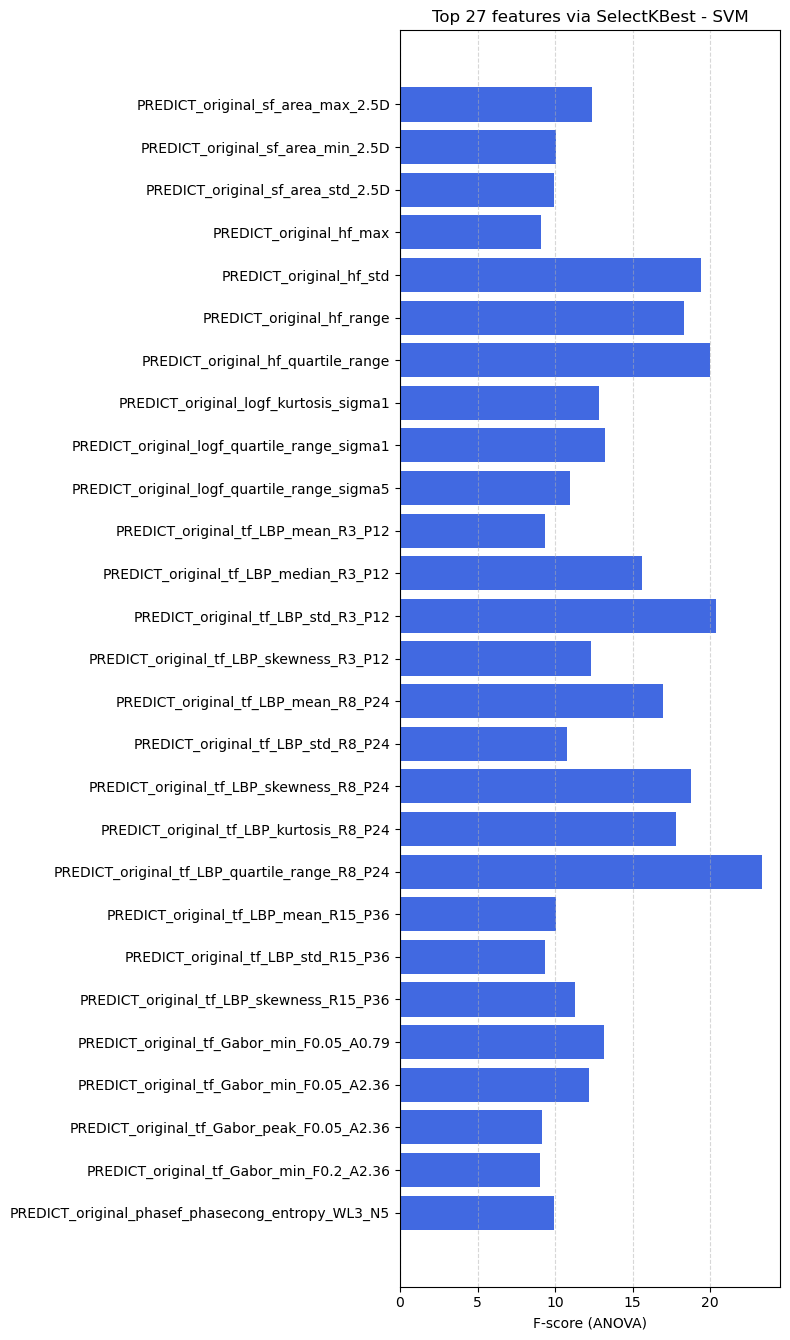

RandomForest → beste k = 29


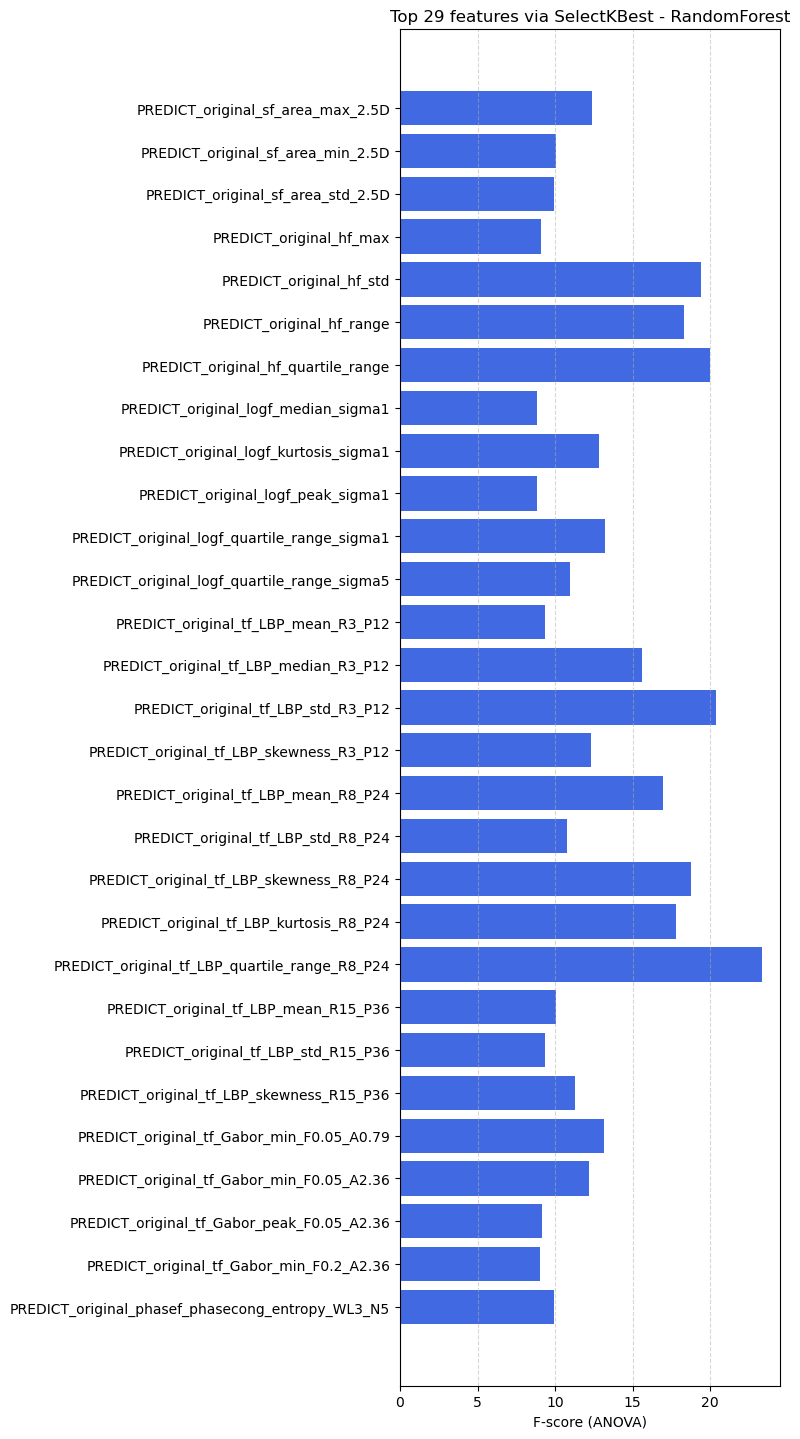

In [60]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif


for model_name, (models, X_input) in models.items():
    # Bepaal het beste k
    k_best = np.argmax(results[model_name]["avg"]) + 1
    print(f"{model_name} → beste k = {k_best}")

    # Pas SelectKBest toe
    selector = SelectKBest(score_func=f_classif, k=k_best)
    selector.fit(X_input, y_train)
    selected_feature_names = X_input.columns[selector.get_support()]
    f_scores = selector.scores_[selector.get_support()]

    # Maak plot
    plt.figure(figsize=(8, max(4, k_best * 0.5)))  # dynamische hoogte
    plt.barh(selected_feature_names, f_scores, color='royalblue')
    plt.xlabel("F-score (ANOVA)")
    plt.title(f"Top {k_best} features via SelectKBest - {model_name}")
    plt.gca().invert_yaxis()  # hoogste bovenaan
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt

# Apply SelectKBest with chi-squared test
selector_chi2 = SelectKBest(score_func=chi2, k=k_best)
X_train_chi2 = selector_chi2.fit_transform(X_train_scaled, y_train)

# Get selected feature names and chi-squared scores
selected_feature_names_chi2 = X_train.columns[selector_chi2.get_support()]
chi2_scores = selector_chi2.scores_[selector_chi2.get_support()]

# Plot the top features based on chi-squared scores
plt.figure(figsize=(8, max(4, k_best * 0.5)))  # dynamic height
plt.barh(selected_feature_names_chi2, chi2_scores, color='teal')
plt.xlabel("Chi-squared Score")
plt.title(f"Top {k_best} Features via Chi-squared Test")
plt.gca().invert_yaxis()  # highest score at the top
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
